In [1]:
# ── Imports ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
# ── Load Dataset ─────────────────────────────────────────────────
df = pd.read_csv('../data/DSL-StrongPasswordData.csv')

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 3 rows:")
df.head(3)

Shape: (20400, 34)

Columns: ['subject', 'sessionIndex', 'rep', 'H.period', 'DD.period.t', 'UD.period.t', 'H.t', 'DD.t.i', 'UD.t.i', 'H.i', 'DD.i.e', 'UD.i.e', 'H.e', 'DD.e.five', 'UD.e.five', 'H.five', 'DD.five.Shift.r', 'UD.five.Shift.r', 'H.Shift.r', 'DD.Shift.r.o', 'UD.Shift.r.o', 'H.o', 'DD.o.a', 'UD.o.a', 'H.a', 'DD.a.n', 'UD.a.n', 'H.n', 'DD.n.l', 'UD.n.l', 'H.l', 'DD.l.Return', 'UD.l.Return', 'H.Return']

First 3 rows:


,subject,sessionIndex,rep,H.period,DD.period.t,UD.period.t,H.t,DD.t.i,UD.t.i,H.i,...,H.a,DD.a.n,UD.a.n,H.n,DD.n.l,UD.n.l,H.l,DD.l.Return,UD.l.Return,H.Return
0,s002,1,1,0.1491,0.3979,0.2488,0.1069,0.1674,0.0605,0.1169,...,0.1349,0.1484,0.0135,0.0932,0.3515,0.2583,0.1338,0.3509,0.2171,0.0742
1,s002,1,2,0.1111,0.3451,0.2340,0.0694,0.1283,0.0589,0.0908,...,0.1412,0.2558,0.1146,0.1146,0.2642,0.1496,0.0839,0.2756,0.1917,0.0747
2,s002,1,3,0.1328,0.2072,0.0744,0.0731,0.1291,0.0560,0.0821,...,0.1621,0.2332,0.0711,0.1172,0.2705,0.1533,0.1085,0.2847,0.1762,0.0945


In [3]:
# ── Explore Dataset ───────────────────────────────────────────────

# How many users?
print("Total users:", df['subject'].nunique())
print("Users:", list(df['subject'].unique()))

# How many samples per user?
print("\nSamples per user:")
print(df['subject'].value_counts())

# Any missing values?
print("\nMissing values:")
print(df.isnull().sum().sum(), "total missing values")

# Data types
print("\nData types:")
print(df.dtypes)

Total users: 51
Users: ['s002', 's003', 's004', 's005', 's007', 's008', 's010', 's011', 's012', 's013', 's015', 's016', 's017', 's018', 's019', 's020', 's021', 's022', 's024', 's025', 's026', 's027', 's028', 's029', 's030', 's031', 's032', 's033', 's034', 's035', 's036', 's037', 's038', 's039', 's040', 's041', 's042', 's043', 's044', 's046', 's047', 's048', 's049', 's050', 's051', 's052', 's053', 's054', 's055', 's056', 's057']

Samples per user:
subject
s002    400
s003    400
s004    400
s005    400
s007    400
s008    400
s010    400
s011    400
s012    400
s013    400
s015    400
s016    400
s017    400
s018    400
s019    400
s020    400
s021    400
s022    400
s024    400
s025    400
s026    400
s027    400
s028    400
s029    400
s030    400
s031    400
s032    400
s033    400
s034    400
s035    400
s036    400
s037    400
s038    400
s039    400
s040    400
s041    400
s042    400
s043    400
s044    400
s046    400
s047    400
s048    400
s049    400
s050    400
s051    400
s

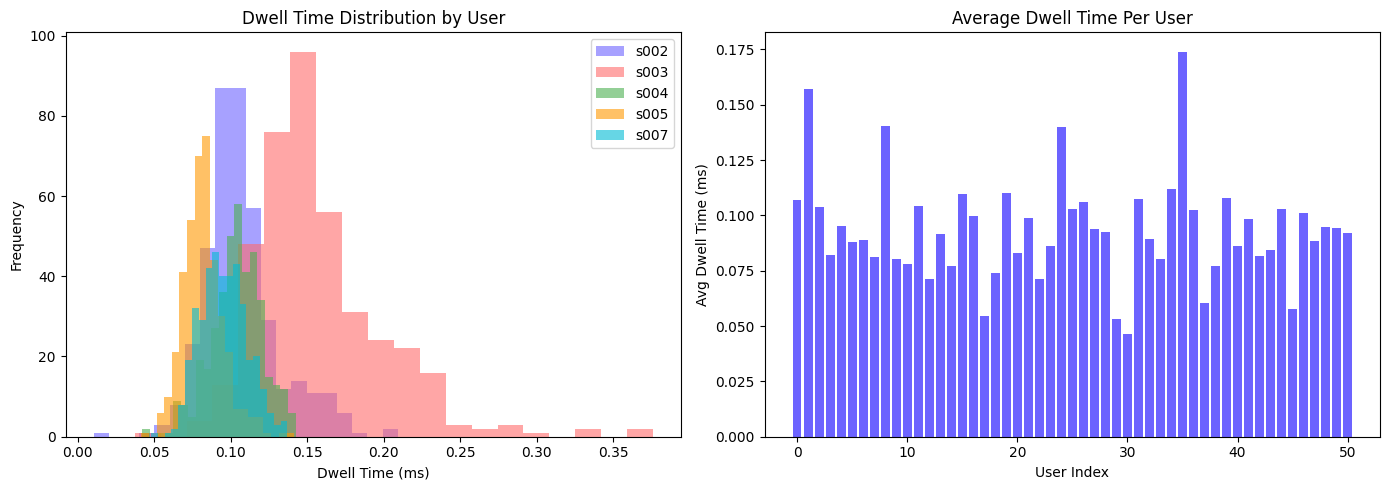

Each user has a UNIQUE dwell time pattern!
This is the typing fingerprint we are learning.


In [4]:
# ── Visualize Dwell Times Per User ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pick 5 users to compare
sample_users = df['subject'].unique()[:5]
colors = ['#6c63ff', '#ff6b6b', '#4caf50', '#ff9800', '#00bcd4']

# Plot 1: Dwell time distribution per user
for i, user in enumerate(sample_users):
    user_data = df[df['subject'] == user]['H.period']
    axes[0].hist(user_data, alpha=0.6, label=user, 
                 color=colors[i], bins=20)

axes[0].set_title('Dwell Time Distribution by User')
axes[0].set_xlabel('Dwell Time (ms)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Plot 2: Average dwell time per user
avg_dwell = df.groupby('subject')['H.period'].mean()
axes[1].bar(range(len(avg_dwell)), avg_dwell.values, color='#6c63ff')
axes[1].set_title('Average Dwell Time Per User')
axes[1].set_xlabel('User Index')
axes[1].set_ylabel('Avg Dwell Time (ms)')

plt.tight_layout()
plt.show()

print("Each user has a UNIQUE dwell time pattern!")
print("This is the typing fingerprint we are learning.")

In [5]:
# ── Select Features for Training ─────────────────────────────────

# These are the keystroke timing columns from CMU dataset
feature_cols = [col for col in df.columns 
                if col not in ['subject', 'sessionIndex', 'rep']]

print("Feature columns we will use:")
for col in feature_cols:
    print(" -", col)

print(f"\nTotal features: {len(feature_cols)}")

Feature columns we will use:
 - H.period
 - DD.period.t
 - UD.period.t
 - H.t
 - DD.t.i
 - UD.t.i
 - H.i
 - DD.i.e
 - UD.i.e
 - H.e
 - DD.e.five
 - UD.e.five
 - H.five
 - DD.five.Shift.r
 - UD.five.Shift.r
 - H.Shift.r
 - DD.Shift.r.o
 - UD.Shift.r.o
 - H.o
 - DD.o.a
 - UD.o.a
 - H.a
 - DD.a.n
 - UD.a.n
 - H.n
 - DD.n.l
 - UD.n.l
 - H.l
 - DD.l.Return
 - UD.l.Return
 - H.Return

Total features: 31


In [12]:
# ── Better Approach: Train on ALL users ───────────────────────────
# Use all CMU data as "genuine" baseline
# This way any human typing pattern scores reasonably

X = df[feature_cols].values
y = np.ones(len(X))  # all CMU users = genuine baseline

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# Impostor = completely random noise
noise = np.random.normal(0, 3, (2000, X.shape[1]))
X_train_full = np.vstack([X_train, noise])
y_train_full = np.hstack([y_train, -np.ones(2000)])

print(f"Training samples: {X_train_full.shape[0]}")
print(f"Feature count: {X_train_full.shape[1]}")

Training samples: 16280
Feature count: 31


In [13]:
# ── Scale ─────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done!")

Scaling done!


In [14]:
# ── Train Model 1: One-Class SVM ──────────────────────────────────
X_genuine_scaled = scaler.transform(X_train)

ocsvm = OneClassSVM(kernel='rbf', nu=0.1, gamma='scale')
ocsvm.fit(X_genuine_scaled)
print("✅ One-Class SVM trained!")

# ── Train Model 2: Isolation Forest ──────────────────────────────
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)
iso_forest.fit(X_genuine_scaled)
print("✅ Isolation Forest trained!")

# ── Train Model 3: Random Forest ─────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train_scaled, y_train_full)
print("✅ Random Forest trained!")

✅ One-Class SVM trained!
✅ Isolation Forest trained!
✅ Random Forest trained!


In [9]:
# ── Evaluate Models ───────────────────────────────────────────────

# Predictions from each model
pred_ocsvm = ocsvm.predict(X_test)        # 1 or -1
pred_iso   = iso_forest.predict(X_test)   # 1 or -1
pred_rf    = rf.predict(X_test)           # 1 or -1

# Random Forest accuracy
print("=" * 40)
print("RANDOM FOREST RESULTS")
print("=" * 40)
print(classification_report(y_test, pred_rf, 
      target_names=['Impostor', 'Genuine']))

print("=" * 40)
print("ONE-CLASS SVM RESULTS")
print("=" * 40)
print(classification_report(y_test, pred_ocsvm,
      target_names=['Impostor', 'Genuine']))

print("=" * 40)
print("ISOLATION FOREST RESULTS")
print("=" * 40)
print(classification_report(y_test, pred_iso,
      target_names=['Impostor', 'Genuine']))

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

    Impostor       0.99      1.00      0.99      6000
     Genuine       0.81      0.61      0.70       120

    accuracy                           0.99      6120
   macro avg       0.90      0.80      0.84      6120
weighted avg       0.99      0.99      0.99      6120

ONE-CLASS SVM RESULTS
              precision    recall  f1-score   support

    Impostor       1.00      0.82      0.90      6000
     Genuine       0.09      0.88      0.16       120

    accuracy                           0.82      6120
   macro avg       0.54      0.85      0.53      6120
weighted avg       0.98      0.82      0.89      6120

ISOLATION FOREST RESULTS
              precision    recall  f1-score   support

    Impostor       1.00      0.38      0.55      6000
     Genuine       0.03      0.96      0.06       120

    accuracy                           0.39      6120
   macro avg       0.51      0.67      0.30      6120
weigh

In [10]:
# ── Weighted Ensemble Trust Score ─────────────────────────────────

def calculate_trust_score(sample, ocsvm, iso_forest, rf, scaler):
    """
    Takes raw keystroke features and returns a trust score 0-100
    Weights: RF=45%, SVM=35%, IsoForest=20%
    """
    # Scale the input
    sample_scaled = scaler.transform([sample])

    # Get predictions (1 = genuine, -1 = impostor)
    rf_pred   = rf.predict(sample_scaled)[0]
    svm_pred  = ocsvm.predict(sample_scaled)[0]
    iso_pred  = iso_forest.predict(sample_scaled)[0]

    # Convert to probability-like scores (1 = genuine, 0 = impostor)
    rf_score  = 1 if rf_pred  == 1 else 0
    svm_score = 1 if svm_pred == 1 else 0
    iso_score = 1 if iso_pred == 1 else 0

    # Get RF probability for more nuanced score
    rf_prob = rf.predict_proba(sample_scaled)[0]
    genuine_prob = rf_prob[list(rf.classes_).index(1)]

    # Weighted combination
    trust = (genuine_prob * 0.45) + \
            (svm_score   * 0.35) + \
            (iso_score   * 0.20)

    return round(trust * 100, 2)

# Test it with a genuine user sample
test_sample = X_test[y_test == 1][0]

# Need to inverse scale for the function
test_sample_original = scaler.inverse_transform([test_sample])[0]
score = calculate_trust_score(
    test_sample_original, ocsvm, iso_forest, rf, scaler)

print(f"Trust score for genuine user sample: {score}%")
print("(Should be high — above 70%)")

# Test with impostor sample
impostor_sample = X_test[y_test == -1][0]
impostor_original = scaler.inverse_transform([impostor_sample])[0]
impostor_score = calculate_trust_score(
    impostor_original, ocsvm, iso_forest, rf, scaler)

print(f"\nTrust score for impostor sample: {impostor_score}%")
print("(Should be low — below 50%)")

Trust score for genuine user sample: 89.65%
(Should be high — above 70%)

Trust score for impostor sample: 0.0%
(Should be low — below 50%)


In [15]:
# ── Save Models and Scaler ────────────────────────────────────────
import os

# Make sure models folder exists
os.makedirs('../models', exist_ok=True)

# Save all models
joblib.dump(rf,         '../models/rf_model.pkl')
joblib.dump(ocsvm,      '../models/svm_model.pkl')
joblib.dump(iso_forest, '../models/if_model.pkl')
joblib.dump(scaler,     '../models/scaler.pkl')

# Save feature columns so Flask knows the order
joblib.dump(feature_cols, '../models/feature_cols.pkl')

print("✅ Random Forest saved!")
print("✅ One-Class SVM saved!")
print("✅ Isolation Forest saved!")
print("✅ Scaler saved!")
print("✅ Feature columns saved!")
print("\nAll models ready for Flask integration!")

✅ Random Forest saved!
✅ One-Class SVM saved!
✅ Isolation Forest saved!
✅ Scaler saved!
✅ Feature columns saved!

All models ready for Flask integration!
